# 🫁 胸部X線画像 — 肺炎分類 CNN (PyTorch)

**データ: HuggingFace `hf-vision/chest-xray-pneumonia`（CC BY 4.0）**

- 5,863枚の実際の胸部X線（正常 / 肺炎）
- **ログイン・シークレット・Kaggleアカウント一切不要**
- ランタイム → **GPU** に変更して上から順に実行してください

## ① ライブラリのインストールと準備

HuggingFace の `datasets` ライブラリでデータを取得します。  
日本語フォントもここでまとめてセットアップします。

In [16]:
!pip install datasets -q
!apt-get install -y fonts-noto-cjk -qq

import matplotlib as mpl
import matplotlib.font_manager as fm
import os

# 正しいキャッシュディレクトリの取得方法
cache_dir = mpl.get_cachedir()  # fm → mpl に変更
print(cache_dir)  # 確認用

# キャッシュを丸ごと削除
import shutil
shutil.rmtree(cache_dir, ignore_errors=True)

# 再構築
fm.fontManager = fm.FontManager()

mpl.rcParams["font.family"] = "Noto Sans CJK JP"

import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch : {torch.__version__}")
print(f"デバイス: {DEVICE}")

/root/.cache/matplotlib
PyTorch : 2.10.0+cu128
デバイス: cuda


## ② データのダウンロード

HuggingFace から胸部X線データセットを取得します。  
**ログイン不要・APIキー不要** で実行できます。

データの内訳:
| split | NORMAL | PNEUMONIA | 合計 |
|---|---|---|---|
| train | 1,342 | 3,876 | 5,218 |
| test  | 234   | 390   | 624  |
| validation | 8 | 8 | 16 |

In [17]:
from datasets import load_dataset

print("データをダウンロード中...")
ds = load_dataset("hf-vision/chest-xray-pneumonia")
print("✅ ダウンロード完了")
print(ds)

# ラベル確認
label_names = ds["train"].features["label"].names
print(f"\nクラス: {label_names}")  # ['NORMAL', 'PNEUMONIA']

データをダウンロード中...
✅ ダウンロード完了
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})

クラス: ['NORMAL', 'PNEUMONIA']


## ③ サンプル画像の確認

実際の胸部X線画像を表示します。

- **正常（NORMAL）**: 肺野が黒く透明に見える
- **肺炎（PNEUMONIA）**: 炎症による白い濁り（浸潤影）が見える

/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1089/1676497776.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu San

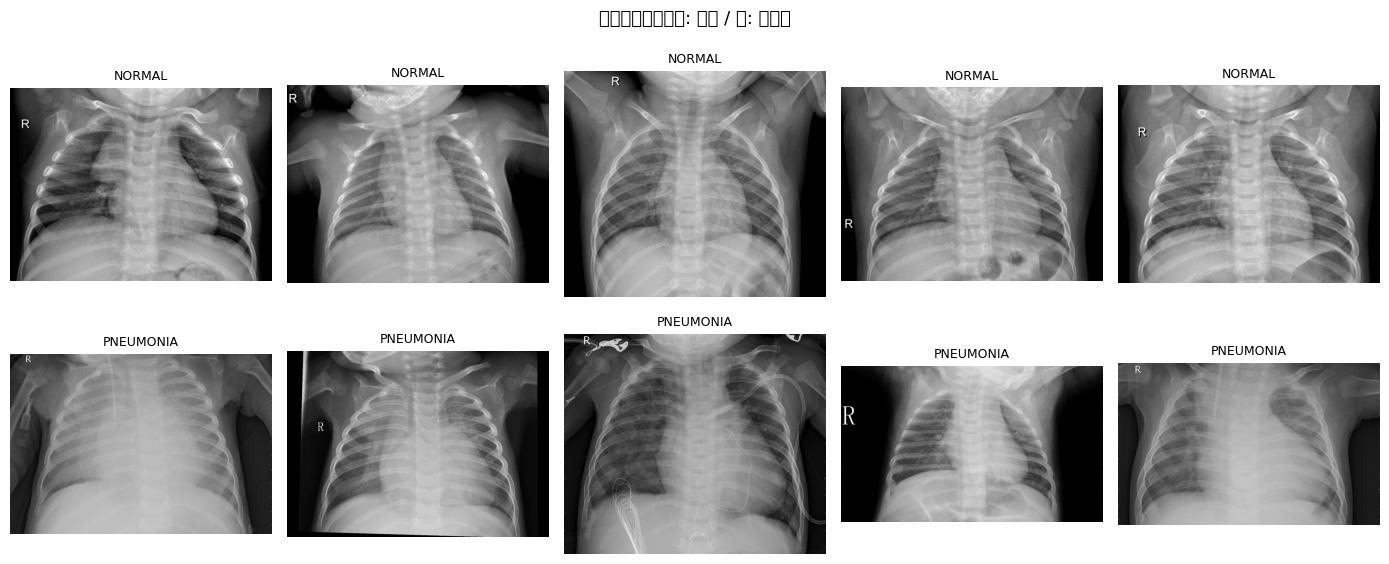

In [18]:
import random

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Images (Top: Normal / Bottom: Pneumonia)", fontsize=13)

for col in range(5):
    for row, (label_id, label_name) in enumerate([(0, "NORMAL"), (1, "PNEUMONIA")]):
        # 該当ラベルのサンプルをランダムに1枚取得
        samples = [x for x in ds["train"] if x["label"] == label_id]
        item = random.choice(samples[:200])  # 先頭200件から選ぶ（高速化）
        img = item["image"].convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(label_name, fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## ④ PyTorch Dataset の作成

HuggingFace の dataset を PyTorch の `DataLoader` で使えるように変換します。

**前処理の流れ:**
```
PIL画像 → グレースケール → 224×224 → Tensor → 正規化
```

訓練時のみ Data Augmentation（水平反転・回転・明度変化）を追加します。

In [19]:
class ChestXrayDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data      = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item["image"].convert("RGB")  # ResNet用にRGB化
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

BATCH_SIZE = 32
IMG_SIZE   = 224

train_tf = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])
test_tf = transforms.Compose([
    transforms.Grayscale(3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3),
])

train_dataset = ChestXrayDataset(ds["train"], transform=train_tf)
test_dataset  = ChestXrayDataset(ds["test"],  transform=test_tf)

# クラス不均衡の補正（肺炎が正常の約3倍 → 均等サンプリング）
train_labels   = [x["label"] for x in ds["train"]]
class_counts   = [train_labels.count(i) for i in range(2)]
weights        = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[torch.tensor(train_labels)]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"クラス  : {label_names}")
print(f"訓練枚数: {len(train_dataset)}  テスト枚数: {len(test_dataset)}")
print(f"NORMAL: {class_counts[0]}枚 / PNEUMONIA: {class_counts[1]}枚")
print("✅ WeightedRandomSampler でクラス不均衡を補正")

クラス  : ['NORMAL', 'PNEUMONIA']
訓練枚数: 5216  テスト枚数: 624
NORMAL: 1341枚 / PNEUMONIA: 3875枚
✅ WeightedRandomSampler でクラス不均衡を補正


## ⑤ モデルの定義（ResNet18 転移学習）

**ResNet18 の転移学習** を使います。

| | スクラッチ学習 | 転移学習（今回）|
|---|---|---|
| 初期重み | ランダム | ImageNet学習済み |
| 必要エポック数 | 多い | 少ない（10で十分）|
| 少ないデータでの精度 | 低め | 高め |

最終層だけ「2クラス分類」に差し替え、全体をFine-tuningします。

In [20]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, 2)
)
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"総パラメータ数: {total:,}")

総パラメータ数: 11,177,538


## ⑥ 学習ループ

| 設定 | 値 |
|---|---|
| エポック数 | 10 |
| 学習率 | 0.0003 |
| 最適化手法 | Adam（weight decay あり）|
| スケジューラー | CosineAnnealingLR |
| 損失関数 | CrossEntropyLoss |

> GPU なら約 5〜10 分、CPU では 30 分以上かかります。**GPU 推奨**。

In [ ]:
EPOCHS = 10
LR     = 3e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss":[], "test_loss":[], "train_acc":[], "test_acc":[]}

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl, tc = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == labels).sum().item()

    model.eval()
    vl, vc = 0.0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            vl += criterion(out, labels).item() * imgs.size(0)
            vc += (out.argmax(1) == labels).sum().item()

    scheduler.step()
    tl /= len(train_dataset); ta = tc / len(train_dataset)
    vl /= len(test_dataset);  va = vc / len(test_dataset)
    for k, v in zip(["train_loss","test_loss","train_acc","test_acc"],[tl,vl,ta,va]):
        history[k].append(v)
    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tl:.4f} acc={ta:.3f}  "
          f"test_loss={vl:.4f} acc={va:.3f}")

print(f"\n🎉 最終テスト精度: {history['test_acc'][-1]*100:.1f}%")

Epoch 01/10  train_loss=0.1258 acc=0.954  test_loss=0.3021 acc=0.915


## ⑦ 学習曲線の可視化

Loss と Accuracy の推移を確認します。

- Train・Test が同じ傾向で改善 → 正常に学習できている ✅
- Test の Loss が上昇に転じたら → 過学習のサイン ⚠️

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Chest X-ray Pneumonia Classification — Learning Curve", fontsize=13)

axes[0].plot(history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(history["test_loss"],  label="Test",  marker="s", markersize=3)
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot([a*100 for a in history["train_acc"]], label="Train", marker="o", markersize=3)
axes[1].plot([a*100 for a in history["test_acc"]],  label="Test",  marker="s", markersize=3)
axes[1].set(title="Accuracy (%)", xlabel="Epoch", ylim=(0, 105))
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

## ⑧ 予測デモ

テストデータから8枚を取り出し、予測結果を表示します。

- **緑タイトル** → 正解 ✅
- **赤タイトル** → 不正解 ❌

In [ ]:
import random

model.eval()

# ランダムに8枚選ぶ
indices = random.sample(range(len(test_loader.dataset)), 8)
imgs_b   = torch.stack([test_loader.dataset[i][0] for i in indices])
labels_b = torch.tensor([test_loader.dataset[i][1] for i in indices])

imgs_b = imgs_b.to(DEVICE)
with torch.no_grad():
    preds = model(imgs_b).argmax(1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Predict Demo (Green=correct / Red=incorrect)", fontsize=13)
for i, ax in enumerate(axes.flat):
    img_show = imgs_b[i].cpu()[0].numpy()
    img_show = np.clip(img_show * 0.229 + 0.485, 0, 1)
    ax.imshow(img_show, cmap="gray")
    color = "green" if preds[i] == labels_b[i] else "red"
    ax.set_title(f"Predict: {label_names[preds[i]]}\nCorrect: {label_names[labels_b[i]]}",
                 color=color, fontsize=8)
    ax.axis("off")
plt.tight_layout(); plt.show()